In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional


def plot_ct3_heatmap(
    csv_path: str | Path,
    *,
    experiment_id: Optional[int] = None,
    value_col: str = "ct3_abs_mean",
    title: str | None = None,
    cmap: str = "viridis",
    figsize=(6, 5),
    annotate: bool = False,
    annotation_fmt: str = ".3g",
) -> None:
    """
    Plot a CT3 heatmap from the aggregated-across-seeds CSV.

    Expected columns include:
      - experiment_id (optional but typical)
      - <theta>, <theta>_prime    (e.g., mu, mu_prime or phi, phi_prime)
      - ct3_signed_mean, ct3_signed_std, ct3_abs_mean, ct3_abs_std, n_seeds, ...

    Parameters
    ----------
    csv_path : str | Path
        Path to CSV.
    experiment_id : int | None
        If provided, filter to this experiment_id. If None and the CSV has multiple
        experiment_ids, the function will raise with a helpful message.
    value_col : str
        Which column to visualize, e.g. "ct3_abs_mean", "ct3_abs_std",
        "ct3_signed_mean", "ct3_signed_std".
    annotate : bool
        If True, write numeric values into each cell.
    """
    df = pd.read_csv(csv_path)

    # ---- handle experiment_id filtering ----
    if "experiment_id" in df.columns:
        exp_ids = sorted(df["experiment_id"].dropna().unique().tolist())
        if experiment_id is None:
            if len(exp_ids) != 1:
                raise ValueError(
                    f"CSV contains multiple experiment_id values {exp_ids}. "
                    "Pass experiment_id=... to select one."
                )
            experiment_id = int(exp_ids[0])

        df = df[df["experiment_id"] == experiment_id].copy()
        if df.empty:
            raise ValueError(f"No rows found for experiment_id={experiment_id} in {csv_path}")

    # ---- infer theta + theta_prime columns ----
    prime_cols = [c for c in df.columns if c.endswith("_prime")]
    if len(prime_cols) == 0:
        raise ValueError(f"No '*_prime' column found in CSV: {list(df.columns)}")
    if len(prime_cols) > 1:
        # If you ever store multiple theta dimensions, this needs explicit args.
        raise ValueError(f"Multiple '*_prime' columns found: {prime_cols}. Specify a simpler CSV.")

    theta_prime = prime_cols[0]
    theta = theta_prime[:-6]  # remove "_prime"

    if theta not in df.columns:
        raise ValueError(f"Inferred theta column '{theta}' not found. Columns: {list(df.columns)}")

    if value_col not in df.columns:
        raise ValueError(f"value_col='{value_col}' not found. Available: {list(df.columns)}")

    # ---- pivot to matrix ----
    heat = (
        df.pivot(index=theta, columns=theta_prime, values=value_col)
        .sort_index()
        .sort_index(axis=1)
    )

    # ---- plot ----
    plt.figure(figsize=figsize)
    im = plt.imshow(
        heat.values,
        origin="lower",
        aspect="auto",
        cmap=cmap,
    )
    plt.colorbar(im, label=value_col)

    plt.xticks(
        ticks=np.arange(len(heat.columns)),
        labels=[f"{v:.3g}" for v in heat.columns],
        rotation=45,
        ha="right",
    )
    plt.yticks(
        ticks=np.arange(len(heat.index)),
        labels=[f"{v:.3g}" for v in heat.index],
    )

    plt.xlabel(theta_prime)
    plt.ylabel(theta)

    if title is None:
        if experiment_id is not None:
            title = f"CT3 heatmap (exp={experiment_id}): {value_col}"
        else:
            title = f"CT3 heatmap: {value_col}"
    plt.title(title)

    # optional annotations
    if annotate:
        for i in range(heat.shape[0]):
            for j in range(heat.shape[1]):
                val = heat.values[i, j]
                if np.isfinite(val):
                    plt.text(j, i, format(val, annotation_fmt), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    # print the filtered df for inspection
    print(df.sort_values([theta, theta_prime]).to_string(index=False))


# Experiment 1: Random Walk Drift

Chronos


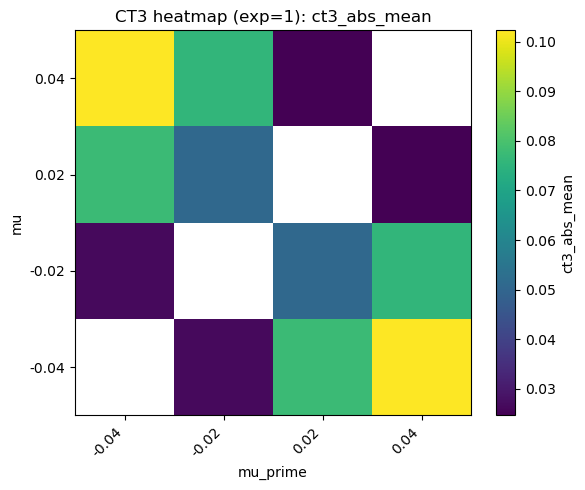

 experiment_id    mu  mu_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             1 -0.04     -0.02         0.026619        0.007497      0.026619     0.007497       10
             1 -0.04      0.02         0.077595        0.017281      0.077595     0.017281       10
             1 -0.04      0.04         0.102261        0.021047      0.102261     0.021047       10
             1 -0.02     -0.04        -0.026619        0.007497      0.026619     0.007497       10
             1 -0.02      0.02         0.050976        0.013576      0.050976     0.013576       10
             1 -0.02      0.04         0.075642        0.017743      0.075642     0.017743       10
             1  0.02     -0.04        -0.077595        0.017281      0.077595     0.017281       10
             1  0.02     -0.02        -0.050976        0.013576      0.050976     0.013576       10
             1  0.02      0.04         0.024666        0.005241      0.024666     0.005241       10


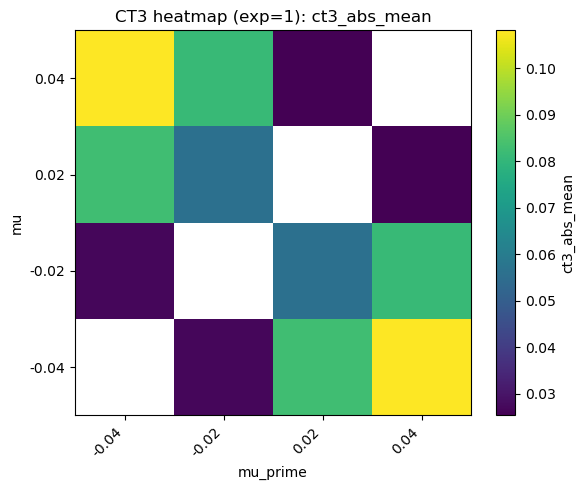

 experiment_id    mu  mu_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             1 -0.04     -0.02         0.026824        0.005923      0.026824     0.005923       10
             1 -0.04      0.02         0.082734        0.012957      0.082734     0.012957       10
             1 -0.04      0.04         0.108119        0.018029      0.108119     0.018029       10
             1 -0.02     -0.04        -0.026824        0.005923      0.026824     0.005923       10
             1 -0.02      0.02         0.055910        0.010803      0.055910     0.010803       10
             1 -0.02      0.04         0.081295        0.015747      0.081295     0.015747       10
             1  0.02     -0.04        -0.082734        0.012957      0.082734     0.012957       10
             1  0.02     -0.02        -0.055910        0.010803      0.055910     0.010803       10
             1  0.02      0.04         0.025385        0.006428      0.025385     0.006428       10


In [8]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/rw_drift_exp_1.csv", experiment_id=1, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/rw_drift_exp_1.csv", experiment_id=1, value_col="ct3_abs_mean")


Both models perform as expected with correct divergence.

# Experiment 2: AR(1)

Chronos


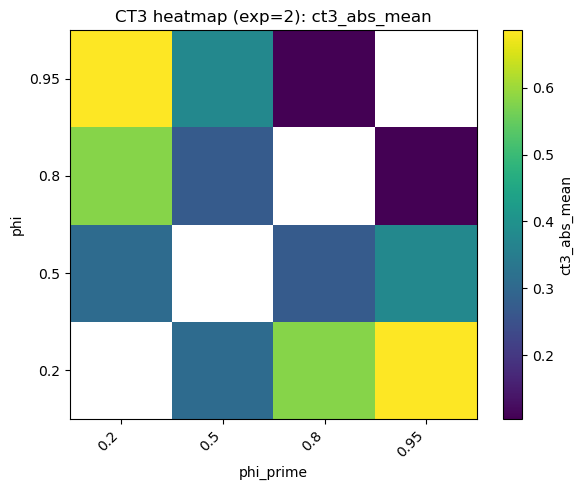

 experiment_id  phi  phi_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             2 0.20       0.50         0.309088        0.008159      0.309088     0.008159       10
             2 0.20       0.80         0.580127        0.019431      0.580127     0.019431       10
             2 0.20       0.95         0.685451        0.021784      0.685451     0.021784       10
             2 0.50       0.20        -0.309088        0.008159      0.309088     0.008159       10
             2 0.50       0.80         0.271039        0.014180      0.271039     0.014180       10
             2 0.50       0.95         0.376363        0.017909      0.376363     0.017909       10
             2 0.80       0.20        -0.580127        0.019431      0.580127     0.019431       10
             2 0.80       0.50        -0.271039        0.014180      0.271039     0.014180       10
             2 0.80       0.95         0.105325        0.008286      0.105325     0.008286       10


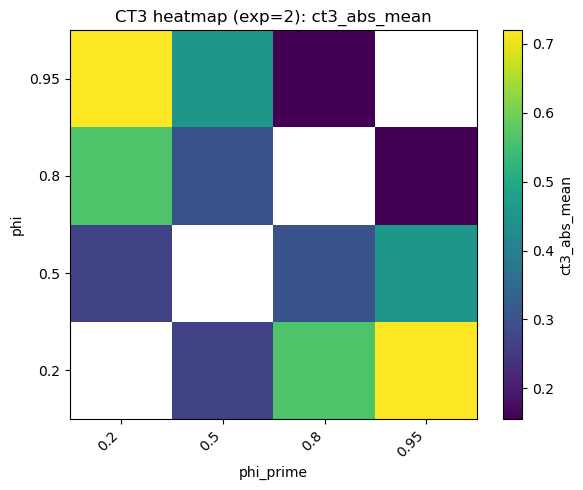

 experiment_id  phi  phi_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             2 0.20       0.50         0.265707        0.003495      0.265707     0.003495       10
             2 0.20       0.80         0.564000        0.011000      0.564000     0.011000       10
             2 0.20       0.95         0.719793        0.014509      0.719793     0.014509       10
             2 0.50       0.20        -0.265707        0.003495      0.265707     0.003495       10
             2 0.50       0.80         0.298293        0.010352      0.298293     0.010352       10
             2 0.50       0.95         0.454086        0.014500      0.454086     0.014500       10
             2 0.80       0.20        -0.564000        0.011000      0.564000     0.011000       10
             2 0.80       0.50        -0.298293        0.010352      0.298293     0.010352       10
             2 0.80       0.95         0.155793        0.010402      0.155793     0.010402       10


In [9]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/ar1_exp_2.csv", experiment_id=2, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/ar1_exp_2.csv", experiment_id=2, value_col="ct3_abs_mean")

Both behave with correct divergence.

# Experiment 3: Harmonic Oscillator

Chronos


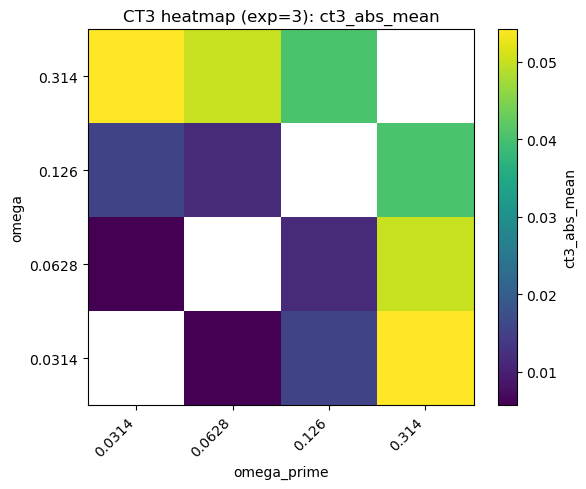

 experiment_id    omega  omega_prime  ct3_abs_mean  ct3_abs_std  n_seeds
             3 0.031416     0.062832      0.005704     0.001396       10
             3 0.031416     0.125664      0.015715     0.000858       10
             3 0.031416     0.314159      0.054181     0.003148       10
             3 0.062832     0.031416      0.005704     0.001396       10
             3 0.062832     0.125664      0.011691     0.000221       10
             3 0.062832     0.314159      0.050122     0.000562       10
             3 0.125664     0.031416      0.015715     0.000858       10
             3 0.125664     0.062832      0.011691     0.000221       10
             3 0.125664     0.314159      0.040431     0.000628       10
             3 0.314159     0.031416      0.054181     0.003148       10
             3 0.314159     0.062832      0.050122     0.000562       10
             3 0.314159     0.125664      0.040431     0.000628       10
TimesFM


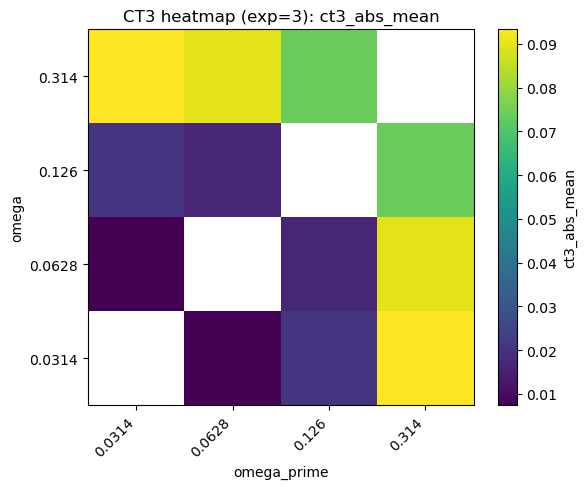

 experiment_id    omega  omega_prime  ct3_abs_mean  ct3_abs_std  n_seeds
             3 0.031416     0.062832      0.007421     0.002604       10
             3 0.031416     0.125664      0.020826     0.002534       10
             3 0.031416     0.314159      0.093289     0.003590       10
             3 0.062832     0.031416      0.007421     0.002604       10
             3 0.062832     0.125664      0.016658     0.002155       10
             3 0.062832     0.314159      0.089813     0.002363       10
             3 0.125664     0.031416      0.020826     0.002534       10
             3 0.125664     0.062832      0.016658     0.002155       10
             3 0.125664     0.314159      0.073594     0.002281       10
             3 0.314159     0.031416      0.093289     0.003590       10
             3 0.314159     0.062832      0.089813     0.002363       10
             3 0.314159     0.125664      0.073594     0.002281       10


In [10]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/harmonic_exp_3.csv", experiment_id=3, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/harmonic_exp_3.csv", experiment_id=3, value_col="ct3_abs_mean")

Both show correct divergence.

# Experiment 4: AR(1) noise

Chronos


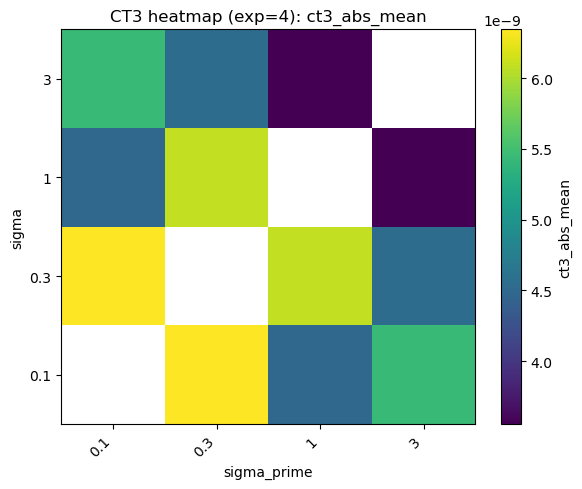

 experiment_id  sigma  sigma_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             4    0.1          0.3    -1.325477e-10    8.331156e-09  6.345461e-09 4.968796e-09       10
             4    0.1          1.0     1.764474e-09    6.242492e-09  4.498308e-09 4.465974e-09       10
             4    0.1          3.0     4.811321e-11    7.574675e-09  5.449792e-09 4.937410e-09       10
             4    0.3          0.1     1.325477e-10    8.331156e-09  6.345461e-09 4.968796e-09       10
             4    0.3          1.0     1.897022e-09    7.487510e-09  6.092170e-09 4.338546e-09       10
             4    0.3          3.0     1.806609e-10    6.563846e-09  4.538195e-09 4.498530e-09       10
             4    1.0          0.1    -1.764474e-09    6.242492e-09  4.498308e-09 4.465974e-09       10
             4    1.0          0.3    -1.897022e-09    7.487510e-09  6.092170e-09 4.338546e-09       10
             4    1.0          3.0    -1.716361e-09    3.531412e

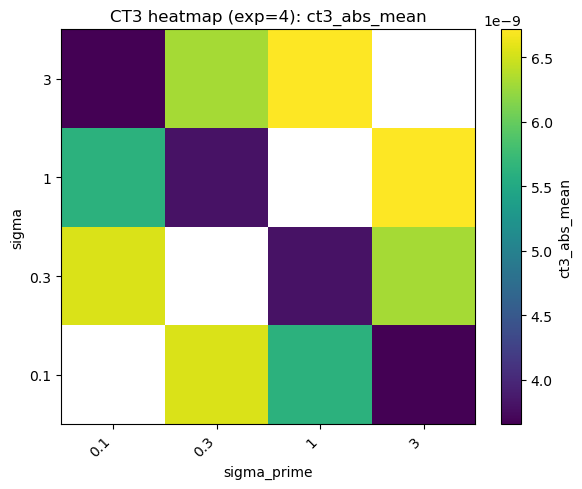

 experiment_id  sigma  sigma_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             4    0.1          0.3     2.128837e-09    8.657298e-09  6.542518e-09 5.694182e-09       10
             4    0.1          1.0    -4.456849e-10    8.791061e-09  5.626552e-09 6.505982e-09       10
             4    0.1          3.0    -3.796422e-10    5.744607e-09  3.656103e-09 4.278823e-09       10
             4    0.3          0.1    -2.128837e-09    8.657298e-09  6.542518e-09 5.694182e-09       10
             4    0.3          1.0    -2.574521e-09    3.624380e-09  3.810264e-09 2.090340e-09       10
             4    0.3          3.0    -2.508479e-09    8.723215e-09  6.299102e-09 6.244893e-09       10
             4    1.0          0.1     4.456849e-10    8.791061e-09  5.626552e-09 6.505982e-09       10
             4    1.0          0.3     2.574521e-09    3.624380e-09  3.810264e-09 2.090340e-09       10
             4    1.0          3.0     6.604267e-11    9.877917e

In [11]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/ar1_exp_4.csv", experiment_id=4, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/ar1_exp_4.csv", experiment_id=4, value_col="ct3_abs_mean")

Practically correct invariance due to miniscule scale of divergence.

# Experiment 5: Harmonic Oscillator amplitude

Chronos


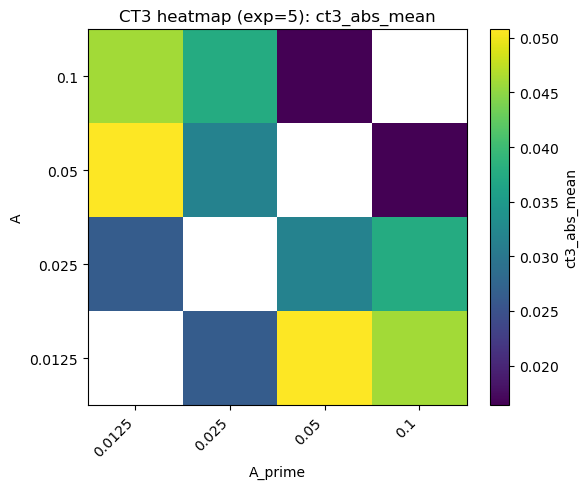

 experiment_id      A  A_prime  ct3_abs_mean  ct3_abs_std  n_seeds
             5 0.0125   0.0250      0.026419     0.016167       10
             5 0.0125   0.0500      0.050781     0.012727       10
             5 0.0125   0.1000      0.046032     0.004635       10
             5 0.0250   0.0125      0.026419     0.016167       10
             5 0.0250   0.0500      0.031575     0.007905       10
             5 0.0250   0.1000      0.037557     0.007937       10
             5 0.0500   0.0125      0.050781     0.012727       10
             5 0.0500   0.0250      0.031575     0.007905       10
             5 0.0500   0.1000      0.016365     0.004859       10
             5 0.1000   0.0125      0.046032     0.004635       10
             5 0.1000   0.0250      0.037557     0.007937       10
             5 0.1000   0.0500      0.016365     0.004859       10
TimesFM


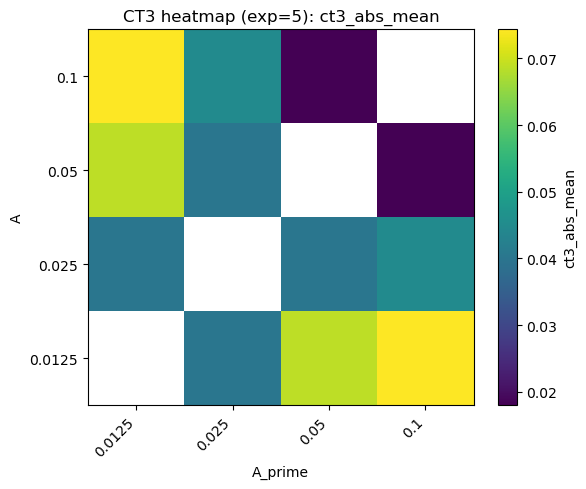

 experiment_id      A  A_prime  ct3_abs_mean  ct3_abs_std  n_seeds
             5 0.0125   0.0250      0.040107     0.018737       10
             5 0.0125   0.0500      0.068673     0.021608       10
             5 0.0125   0.1000      0.074359     0.018144       10
             5 0.0250   0.0125      0.040107     0.018737       10
             5 0.0250   0.0500      0.040173     0.019853       10
             5 0.0250   0.1000      0.044909     0.019533       10
             5 0.0500   0.0125      0.068673     0.021608       10
             5 0.0500   0.0250      0.040173     0.019853       10
             5 0.0500   0.1000      0.017994     0.004722       10
             5 0.1000   0.0125      0.074359     0.018144       10
             5 0.1000   0.0250      0.044909     0.019533       10
             5 0.1000   0.0500      0.017994     0.004722       10


In [12]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/harmonic_exp_5.csv", experiment_id=5, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/harmonic_exp_5.csv", experiment_id=5, value_col="ct3_abs_mean")

Incorrect variance by both. TimesFM's wavelength estimate seems to be more sensitive to changes in amplitude.